# Table of Contents

| Part | Section |
|--------|------------|
| Part 1: Overall Expense Overview | 1.1. Total Expenses by Currency |
| &nbsp; | 1.2. Total Expenses in KRW |
| &nbsp; | 1.3. Daily Average & Expense Trend |
| Part 2: Time-Series Expenditure Analysis | 2.1. Monthly Spending Trend |
| &nbsp; | 2.2. Spending by Period |
| Part 3: Category & Travel Expense Analysis | 3.1. Total Expenses by Category |
| &nbsp; | 3.2. Monthly Top 3 Categories |
| &nbsp; | 3.3. Travel-Specific Analysis |

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
# Load the dataset
df = pd.read_csv('exchange_expenses_dataset.csv')

# Convert date column to datetime object
df['지출 날짜'] = pd.to_datetime(df['지출 날짜'])

***

### Part 1: Overall Expense Overview

1. **Total Expenses by Currency**: A summary table displaying the aggregate amount spent across different currencies (e.g., EUR, KRW, USD, GBP, CHF, TRY).
2. **Total Expenses in KRW**: The grand total of all expenses converted to Korean Won (KRW) during the exchange period.
3. **Daily Average & Expense Trend**: A daily time-series plot visualizing the expense flow from Day 1 to Day N (Aug 22, 2025 ~ Jan 31, 2026), including the calculated average daily spending.

=== 1.1 Total Expenses by Currency ===


,Currency,Total Amount
0,EUR,4772.68
1,KRW,7399464.00
2,USD,765.40
3,GBP,30.83
4,CHF,608.80
5,TRY,1337.78




=== 1.2 Total Expenses Converted to KRW ===
Grand Total (KRW): 17,570,677 KRW

=== 1.3 Daily Average Expense During Stay ===
Stay Period: 2025-08-22 ~ 2026-01-31 (163 days)
Total Spent During Stay: 12,019,543 KRW
Daily Average: 73,740 KRW



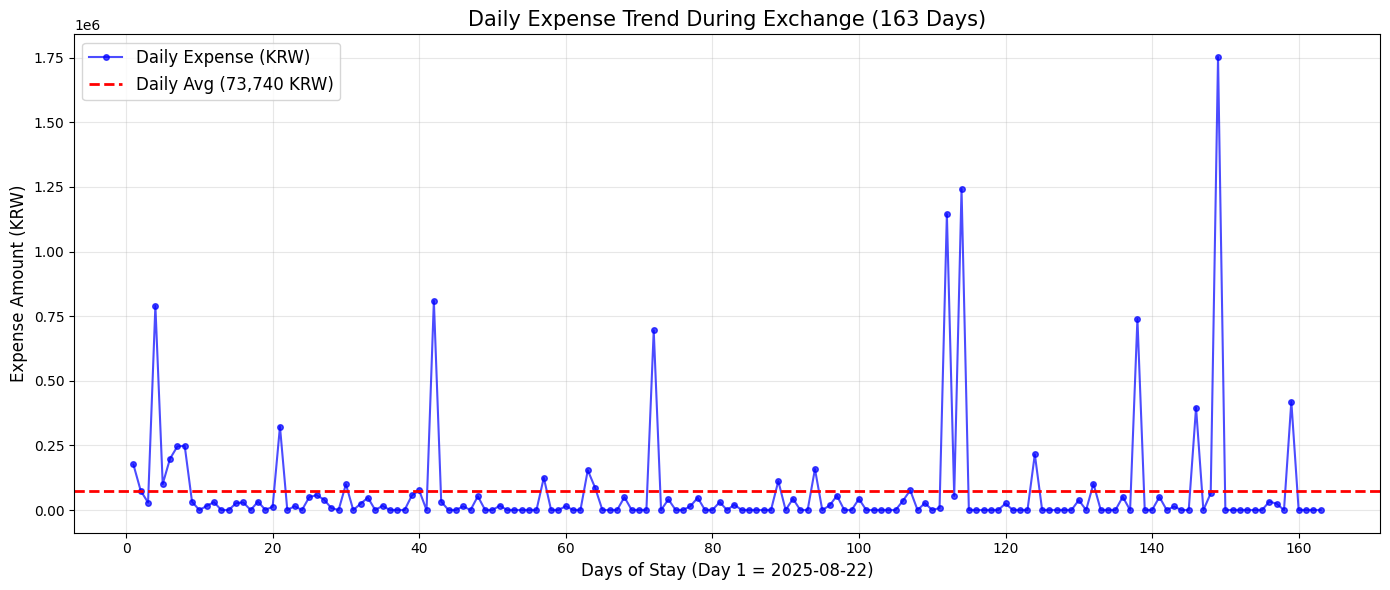

In [11]:
# =========================================================
# 1.1 Total Expenses by Currency
# =========================================================
# Define currency columns based on the dataset
currency_cols = [
    '지출 금액 EUR', '지출 금액 KRW', '지출 금액 USD', 
    '지출 금액 GBP', '지출 금액 CHF', '지출 금액 TRY'
]

# Calculate total for each currency
total_by_currency = df[currency_cols].sum().reset_index()
total_by_currency.columns = ['Currency', 'Total Amount']

# Clean up currency names (e.g., '지출 금액 EUR' -> 'EUR')
total_by_currency['Currency'] = total_by_currency['Currency'].str.replace('지출 금액 ', '')

print("=== 1.1 Total Expenses by Currency ===")
display(total_by_currency) # Use display() in Jupyter Notebook for a formatted table
print("\n")


# =========================================================
# 1.2 Total Expenses in KRW
# =========================================================
total_krw = df['expense_krw'].sum()
print("=== 1.2 Total Expenses Converted to KRW ===")
print(f"Grand Total (KRW): {total_krw:,.0f} KRW\n")


# =========================================================
# 1.3 Daily Average Expense & Trend Plot (During Exchange)
# =========================================================
# Define the exact stay period
start_date = pd.to_datetime('2025-08-22')
end_date = pd.to_datetime('2026-01-31')

# Generate a full date range to account for days with zero expenses
full_date_range = pd.date_range(start=start_date, end=end_date)
num_days = len(full_date_range)

# Filter dataset for the exchange period
exchange_df = df[(df['지출 날짜'] >= start_date) & (df['지출 날짜'] <= end_date)]

# Group by date and sum the daily KRW expenses
daily_expenses = exchange_df.groupby('지출 날짜')['expense_krw'].sum()

# Reindex to include days with 0 expenses
daily_expenses = daily_expenses.reindex(full_date_range, fill_value=0)

# Calculate total and daily average for the stay period
total_exchange_krw = daily_expenses.sum()
daily_average = total_exchange_krw / num_days

print("=== 1.3 Daily Average Expense During Stay ===")
print(f"Stay Period: {start_date.date()} ~ {end_date.date()} ({num_days} days)")
print(f"Total Spent During Stay: {total_exchange_krw:,.0f} KRW")
print(f"Daily Average: {daily_average:,.0f} KRW\n")

# Plotting the daily expenses
plt.figure(figsize=(14, 6))

# X-axis: Day 1 to Day N
days = range(1, num_days + 1)
plt.plot(days, daily_expenses.values, marker='o', linestyle='-', color='b', 
         markersize=4, alpha=0.7, label='Daily Expense (KRW)')

# Add horizontal line for the daily average
plt.axhline(y=daily_average, color='red', linestyle='--', linewidth=2, 
            label=f'Daily Avg ({daily_average:,.0f} KRW)')

# Formatting the plot
plt.title(f'Daily Expense Trend During Exchange ({num_days} Days)', fontsize=15)
plt.xlabel('Days of Stay (Day 1 = 2025-08-22)', fontsize=12)
plt.ylabel('Expense Amount (KRW)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

***

### Part 2: Time-Series Expenditure Analysis

1. **Monthly Spending Trend**: A summary table and bar chart showing the total expenses for each month to identify periods with the highest spending.
2. **Spending by Period**: A comparison table of total expenses categorized into 'Before', 'Exchange', and 'After' to understand the distribution of costs across different stages of the exchange program.

=== 2.1 Monthly Spending Summary ===


,Month,Total Spending (KRW)
0,2025-07,2705596
1,2025-08,5271240
2,2025-09,965793
3,2025-10,1357759
4,2025-11,1282243
5,2025-12,2970750
6,2026-01,3546065
7,2026-02,-16000
8,2026-03,-512769


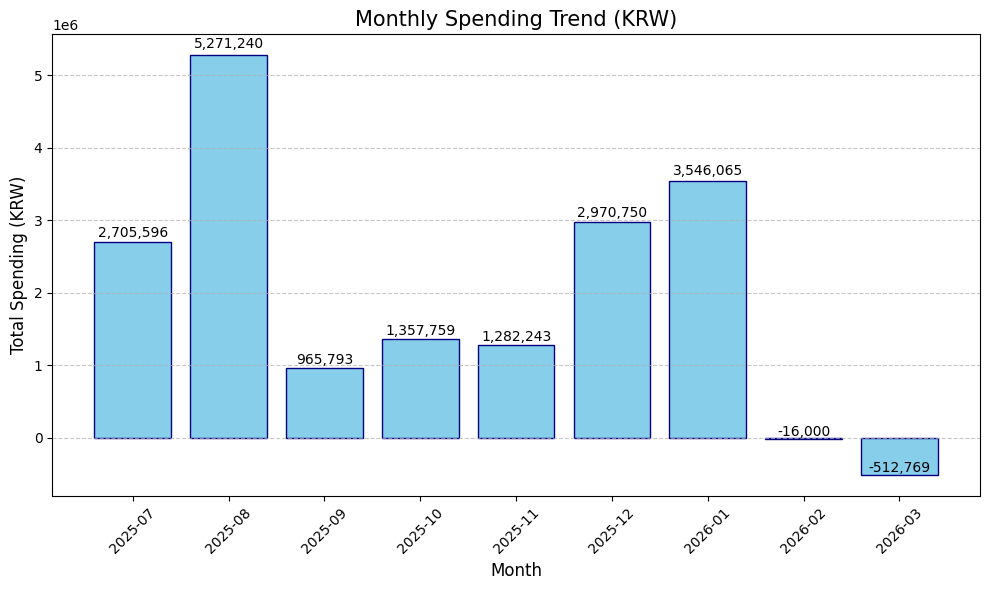

=== 2.2 Spending Comparison by Period ===


,Period,Total Spending (KRW),Percentage (%)
1,Before,6127443,34.87
2,Exchange,11972003,68.14
0,After,-528769,-3.01


In [12]:
# =========================================================
# 2.1 Monthly Spending Trend
# =========================================================
# Group by '지출 월' (Spending Month) and sum the 'expense_krw'
monthly_spending = df.groupby('지출 월')['expense_krw'].sum().reset_index()
monthly_spending.columns = ['Month', 'Total Spending (KRW)']

# Sort by month to ensure chronological order in the table and plot
monthly_spending = monthly_spending.sort_values(by='Month')

print("=== 2.1 Monthly Spending Summary ===")
display(monthly_spending)
print("\n")

# Plotting Monthly Spending Trend
plt.figure(figsize=(10, 6))
bars = plt.bar(monthly_spending['Month'], monthly_spending['Total Spending (KRW)'], color='skyblue', edgecolor='navy')

# Add labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), f'{int(yval):,}', 
             ha='center', va='bottom', fontsize=10)

plt.title('Monthly Spending Trend (KRW)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Spending (KRW)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# =========================================================
# 2.2 Spending Comparison by Period (Before, Exchange, After)
# =========================================================
# Group by '결제 시기' (Payment Period) and sum 'expense_krw'
# The categories are likely 'Before', 'Exchange', and 'After'
period_spending = df.groupby('결제 시기')['expense_krw'].sum().reset_index()
period_spending.columns = ['Period', 'Total Spending (KRW)']

# Optional: Reorder the categories for better logical flow
period_order = ['Before', 'Exchange', 'After']
period_spending['Period'] = pd.Categorical(period_spending['Period'], categories=period_order, ordered=True)
period_spending = period_spending.sort_values('Period')

# Calculate percentage for additional insight
total_sum = period_spending['Total Spending (KRW)'].sum()
period_spending['Percentage (%)'] = (period_spending['Total Spending (KRW)'] / total_sum * 100).round(2)

print("=== 2.2 Spending Comparison by Period ===")
display(period_spending)

***

### Part 3: Category & Travel Expense Analysis

1. **Total Expenses by Category**: A breakdown of spending across different categories (Food, Housing, Travel, etc.) in KRW, including their relative proportions.
2. **Monthly Top 3 Categories**: An analysis of the primary spending drivers for each month, identifying the top three categories and their combined share of the monthly budget.
3. **Travel-Specific Analysis**: A focused look at the total expenditure related to 'Travel' and its overall percentage compared to the total exchange expenses.

=== 3.1 Spending by Category ===


Category,Total (KRW),Percentage (%)
여행,5001952,28.470000
식료품+생활,3106419,17.680000
서류,2581136,14.690000
기숙사,2375176,13.520000
항공,2067709,11.770000
교통,1054535,6.000000
쇼핑,427180,2.430000
기타,325572,1.850000
보험,231353,1.320000
핸드폰,193745,1.100000


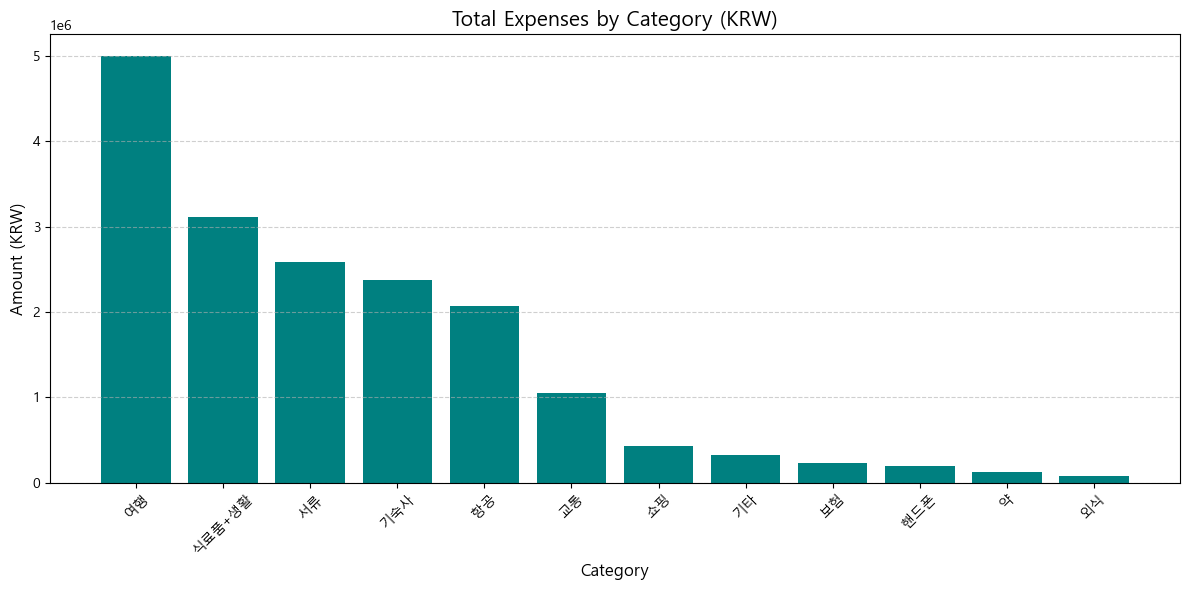

=== 3.2 Monthly Top 3 Spending Categories ===


,지출 월,Top 1 Category,Top 2 Category,Top 3 Category,Total of Top 3 (KRW),Top 3 Share (%)
0,2025-07,서류,기숙사,보험,2705596,100.00
1,2025-08,기숙사,식료품+생활,항공,3479837,66.02
2,2025-09,식료품+생활,여행,핸드폰,949776,98.34
3,2025-10,기숙사,식료품+생활,교통,1334439,98.28
4,2025-11,기숙사,식료품+생활,교통,1258370,98.14
5,2025-12,여행,항공,식료품+생활,2692862,90.65
6,2026-01,여행,식료품+생활,핸드폰,3517087,99.18
7,2026-02,핸드폰,None,None,-16000,100.00
8,2026-03,기숙사,None,None,-512769,100.00




=== 3.3 Travel Category Summary ===


,Metric,Value
0,Total Travel Expenses,"5,001,952 KRW"
1,Percentage of Grand Total,28.47%


In [25]:
import platform

# =========================================================
# Set Korean Font based on OS
# =========================================================
if platform.system() == 'Darwin': # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows': # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # Fix for negative signs in plots

# =========================================================
# 3.1 Total Expenses by Category
# =========================================================
# Group by category and sum KRW expenses
category_spending = df.groupby('지출 항목')['expense_krw'].sum().reset_index()
category_spending.columns = ['Category', 'Total (KRW)']

# Calculate percentage
total_krw = category_spending['Total (KRW)'].sum()
category_spending['Percentage (%)'] = (category_spending['Total (KRW)'] / total_krw * 100).round(2)

# Sort by amount descending
category_spending = category_spending.sort_values(by='Total (KRW)', ascending=False)

print("=== 3.1 Spending by Category ===")
display(category_spending.style.hide(axis='index'))
print("\n")

# Visualization: Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(category_spending['Category'], category_spending['Total (KRW)'], color='teal')
plt.title('Total Expenses by Category (KRW)', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Amount (KRW)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# =========================================================
# 3.2 Monthly Top 3 Categories Analysis
# =========================================================
# Group by month and category
monthly_cat = df.groupby(['지출 월', '지출 항목'])['expense_krw'].sum().reset_index()

def get_top_3_with_ratio(group):
    total_month = group['expense_krw'].sum()
    top_3 = group.sort_values(by='expense_krw', ascending=False).head(3)
    
    top_3_names = top_3['지출 항목'].tolist()
    top_3_sum = top_3['expense_krw'].sum()
    top_3_share = (top_3_sum / total_month * 100).round(2)
    
    return pd.Series({
        'Top 1 Category': top_3_names[0] if len(top_3_names) > 0 else None,
        'Top 2 Category': top_3_names[1] if len(top_3_names) > 1 else None,
        'Top 3 Category': top_3_names[2] if len(top_3_names) > 2 else None,
        'Total of Top 3 (KRW)': top_3_sum,
        'Top 3 Share (%)': top_3_share
    })

monthly_top_summary = (
    monthly_cat.groupby('지출 월')
    .apply(get_top_3_with_ratio, include_groups=False)
    .reset_index()
)

print("=== 3.2 Monthly Top 3 Spending Categories ===")
display(monthly_top_summary)
print("\n")


# =========================================================
# 3.3 Travel Category Proportion
# =========================================================
# Filter for '여행' (Travel) category
travel_data = category_spending[category_spending['Category'] == '여행']

if not travel_data.empty:
    travel_total = travel_data['Total (KRW)'].values[0]
    travel_ratio = travel_data['Percentage (%)'].values[0]
else:
    travel_total = 0
    travel_ratio = 0

travel_summary = pd.DataFrame({
    'Metric': ['Total Travel Expenses', 'Percentage of Grand Total'],
    'Value': [f"{travel_total:,.0f} KRW", f"{travel_ratio}%"]
})

print("=== 3.3 Travel Category Summary ===")
display(travel_summary)